# Image Denoising with an Autoencoder on MNIST

This project builds a deep learning model that removes noise from images. The idea behind a denoising autoencoder is simple and elegant. We take a clean image, deliberately corrupt it with random noise, and then train a network to rebuild the clean version from the noisy one. To do that well the model has to learn what a digit actually looks like and throw away everything that does not belong.

We build two versions and compare them:

1. A fully connected (linear) autoencoder as a baseline
2. A convolutional autoencoder that works directly on the image grid

Both are trained on MNIST, the classic dataset of handwritten digits.

## Problem statement

Given a grayscale image of a handwritten digit that has been degraded with noise, we want a model that outputs a clean version of the same digit.

The setup works like this. Each training image is normalized so its pixel values sit between 0 and 1. We add random Gaussian noise to a copy of the image and clip it back into the valid range. The noisy copy becomes the input to the model, and the original clean image becomes the target. The model learns by minimizing the difference between its output and the clean target.

An autoencoder has two halves. The encoder squeezes the input down into a small compressed representation, and the decoder expands that representation back into a full image. Because the compressed form is much smaller than the image, the network cannot simply copy pixels across. It is forced to keep only the information that matters, which is exactly what makes it good at dropping noise.

## Setup

The cell below imports everything and picks a GPU if one is available. On Colab or Kaggle a GPU makes training much faster, but the notebook runs fine on CPU too. Random seeds are fixed so the runs stay reasonably repeatable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch version:", torch.__version__)
print("Using device:", device)

PyTorch version: 2.11.0+cpu
Using device: cpu


If the device prints as cuda the model will train on the GPU. If it prints cpu everything still works, it just takes longer.

## Loading MNIST

MNIST is a standard benchmark, so the cleanest way to get it is to let torchvision download and cache it directly. There is no need to handle files or folders by hand. The dataset has 60,000 training images and 10,000 test images, each one a 28 by 28 grayscale picture of a single digit.

We carve a validation set of 12,000 images out of the training set, which leaves 48,000 for training. The validation set lets us watch how the model does on data it is not learning from.

On Kaggle, make sure internet is turned on in the notebook settings so the download can run.

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

full_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    full_train, [48000, 12000],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Training images:  ", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:      ", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 133MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 16.6MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 117MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.12MB/s]


Training images:   48000
Validation images: 12000
Test images:       10000


The three loaders feed data to the model in batches. ToTensor already scales the pixels into the 0 to 1 range, which is why we will be able to use a sigmoid on the output later to match that same range.

## A look at the clean digits

Before adding any noise, here are a few images straight from the dataset so we know what a clean target looks like.

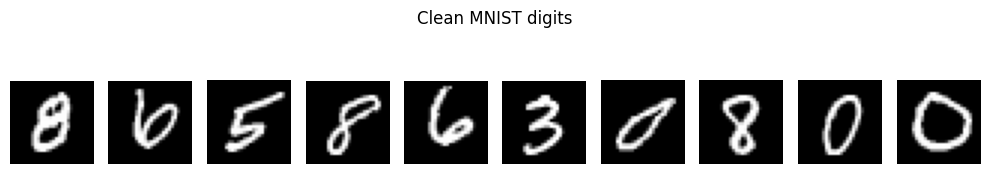

In [3]:
sample_images, _ = next(iter(train_loader))

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(sample_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle("Clean MNIST digits")
plt.tight_layout()
plt.show()

These are the digits the model should ultimately produce. Our job is to hand it a messy version of each one and have it recover something close to this.

## Adding noise

This is the heart of a denoising autoencoder. For every image we add Gaussian noise scaled by a noise factor, then clip the result so pixels stay between 0 and 1. A higher noise factor makes the images harder to read and the task tougher.

We also settle the choice of loss here. Since we are comparing pixel intensities in the output against the clean image, this is a regression problem rather than a classification one. Mean squared error is the natural fit, because it directly measures how far each predicted pixel is from the true pixel.

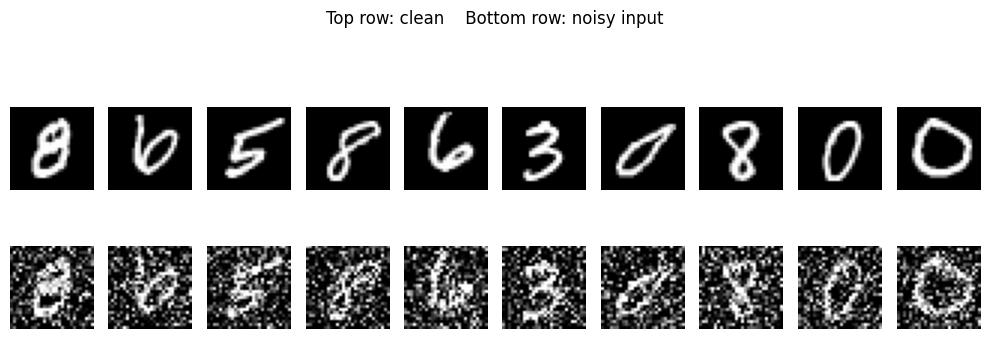

In [4]:
NOISE_FACTOR = 0.5

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0.0, 1.0)


noisy_samples = add_noise(sample_images)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(sample_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
    plt.subplot(2, 10, i + 11)
    plt.imshow(noisy_samples[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle("Top row: clean    Bottom row: noisy input")
plt.tight_layout()
plt.show()

The bottom row is what the model actually sees during training. The digits are still faintly visible to us, and the goal is for the network to learn to bring them back cleanly.

## Model 1: Linear autoencoder

The baseline flattens each 28 by 28 image into a vector of 784 values and passes it through a few fully connected layers. The encoder shrinks the vector down to a small code, and the decoder grows it back to 784 values. A sigmoid on the final layer keeps the output in the 0 to 1 range so it matches the input.

The weights of the linear layers are initialized from a normal distribution with a small standard deviation, following the same idea used in the reference implementation. Starting the weights near zero tends to make early training more stable.

In [5]:
class LinearDenoisingAE(nn.Module):
    def __init__(self, hidden=256, latent=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, hidden),
            nn.ReLU(),
            nn.Linear(hidden, latent),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        batch = x.size(0)
        x = x.view(batch, -1)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(batch, 1, 28, 28)


def init_linear_weights(m):
    if isinstance(m, nn.Linear):
        n = m.in_features
        m.weight.data.normal_(0.0, 1.0 / np.sqrt(n))
        m.bias.data.fill_(0.0)


linear_ae = LinearDenoisingAE().to(device)
linear_ae.apply(init_linear_weights)
print(linear_ae)

LinearDenoisingAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


The compressed code here is a vector of length 64, far smaller than the 784 input values. That bottleneck is what pushes the model to keep only the essential shape of each digit.

## Model 2: Convolutional autoencoder

Flattening an image throws away the fact that nearby pixels belong together. A convolutional model keeps the image as a grid and slides small filters over it, so it naturally picks up strokes and curves. This usually makes it much better at image tasks than a plain linear network.

The encoder uses two convolution and pooling stages to shrink the image from 28 by 28 down to a compact 4 by 7 by 7 representation. The decoder then grows it back up. Rather than transposed convolutions, which can leave a faint checkerboard pattern, the decoder uses nearest neighbor upsampling followed by ordinary convolutions. This is the cleaner approach recommended in the reference material, and it avoids those artifacts.

In [6]:
class ConvDenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),   # 16 x 28 x 28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 16 x 14 x 14
            nn.Conv2d(16, 4, 3, padding=1),   # 4 x 14 x 14
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 4 x 7 x 7
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),   # 4 x 14 x 14
            nn.Conv2d(4, 16, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),   # 16 x 28 x 28
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


conv_ae = ConvDenoisingAE().to(device)
print(conv_ae)

ConvDenoisingAE(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): Upsample(scale_factor=2.0, mode='nearest')
    (4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


The encoder squeezes each image down to 4 by 7 by 7, which is 196 numbers, about a quarter of the original 784 pixels. The decoder rebuilds a full 28 by 28 image from that compact code, and the sigmoid at the end keeps the pixels in range.

## Training

Both models train the same way, so we write one training function and reuse it. For each batch we build a noisy copy of the images, feed it in, and compare the output against the clean originals using mean squared error. The optimizer is Adam, and we train for 20 epochs while tracking both the training and validation loss.

In [7]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())


def train_model(model, epochs=20, lr=1e-3, noise_factor=NOISE_FACTOR):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train': [], 'val': []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            noisy = add_noise(images, noise_factor)
            optimizer.zero_grad()
            outputs = model(noisy)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                noisy = add_noise(images, noise_factor)
                outputs = model(noisy)
                val_loss += criterion(outputs, images).item() * images.size(0)
        val_loss /= len(val_loader.dataset)

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        print(f"Epoch {epoch:2d}/{epochs}   train loss: {train_loss:.4f}   val loss: {val_loss:.4f}")

    return history

Notice that the target is always the clean image while the input is the noisy one. That single choice is what turns a plain autoencoder into a denoising autoencoder.

In [8]:
print("Training the linear autoencoder")
linear_history = train_model(linear_ae)

Training the linear autoencoder
Epoch  1/20   train loss: 0.0484   val loss: 0.0304
Epoch  2/20   train loss: 0.0271   val loss: 0.0248
Epoch  3/20   train loss: 0.0234   val loss: 0.0224
Epoch  4/20   train loss: 0.0219   val loss: 0.0215
Epoch  5/20   train loss: 0.0211   val loss: 0.0208
Epoch  6/20   train loss: 0.0205   val loss: 0.0202
Epoch  7/20   train loss: 0.0201   val loss: 0.0201
Epoch  8/20   train loss: 0.0197   val loss: 0.0194
Epoch  9/20   train loss: 0.0193   val loss: 0.0191
Epoch 10/20   train loss: 0.0190   val loss: 0.0188
Epoch 11/20   train loss: 0.0187   val loss: 0.0186
Epoch 12/20   train loss: 0.0184   val loss: 0.0183
Epoch 13/20   train loss: 0.0182   val loss: 0.0182
Epoch 14/20   train loss: 0.0179   val loss: 0.0178
Epoch 15/20   train loss: 0.0177   val loss: 0.0177
Epoch 16/20   train loss: 0.0174   val loss: 0.0174
Epoch 17/20   train loss: 0.0172   val loss: 0.0172
Epoch 18/20   train loss: 0.0170   val loss: 0.0170
Epoch 19/20   train loss: 0.0169

The linear model trains quickly since it is just a few dense layers. Its loss should fall steadily, though there is a limit to how sharp its output can get because it ignores the spatial layout of the image.

In [9]:
print("Training the convolutional autoencoder")
conv_history = train_model(conv_ae)

Training the convolutional autoencoder
Epoch  1/20   train loss: 0.0688   val loss: 0.0279
Epoch  2/20   train loss: 0.0251   val loss: 0.0235
Epoch  3/20   train loss: 0.0228   val loss: 0.0221
Epoch  4/20   train loss: 0.0217   val loss: 0.0213
Epoch  5/20   train loss: 0.0210   val loss: 0.0206
Epoch  6/20   train loss: 0.0203   val loss: 0.0200
Epoch  7/20   train loss: 0.0196   val loss: 0.0194
Epoch  8/20   train loss: 0.0191   val loss: 0.0188
Epoch  9/20   train loss: 0.0187   val loss: 0.0184
Epoch 10/20   train loss: 0.0184   val loss: 0.0181
Epoch 11/20   train loss: 0.0181   val loss: 0.0180
Epoch 12/20   train loss: 0.0179   val loss: 0.0177
Epoch 13/20   train loss: 0.0177   val loss: 0.0176
Epoch 14/20   train loss: 0.0175   val loss: 0.0174
Epoch 15/20   train loss: 0.0174   val loss: 0.0173
Epoch 16/20   train loss: 0.0173   val loss: 0.0172
Epoch 17/20   train loss: 0.0172   val loss: 0.0172
Epoch 18/20   train loss: 0.0171   val loss: 0.0172
Epoch 19/20   train loss:

The convolutional model has more work to do per batch, but it tends to reach a lower loss because it understands the image as a grid rather than a flat list of numbers.

## Comparing the training curves

Plotting the loss for both models side by side shows how each one learns and how far each one gets.

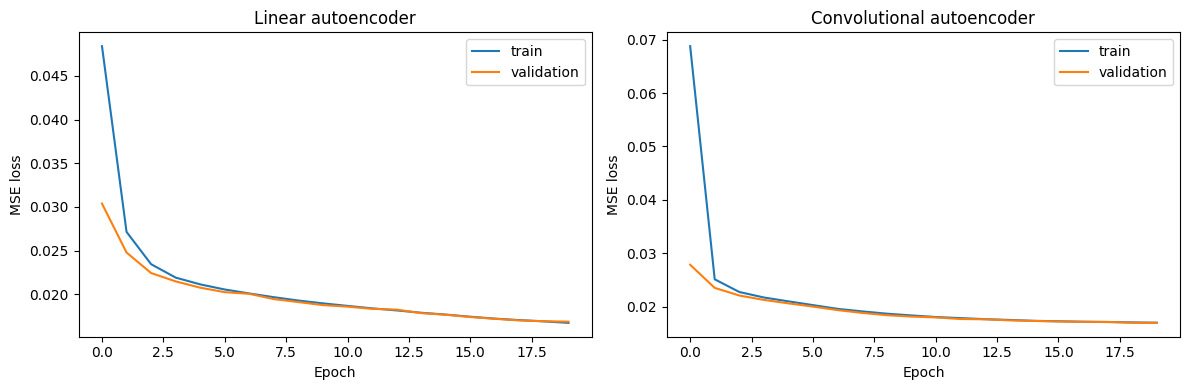

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(linear_history['train'], label='train')
ax[0].plot(linear_history['val'], label='validation')
ax[0].set_title("Linear autoencoder")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("MSE loss")
ax[0].legend()

ax[1].plot(conv_history['train'], label='train')
ax[1].plot(conv_history['val'], label='validation')
ax[1].set_title("Convolutional autoencoder")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE loss")
ax[1].legend()

plt.tight_layout()
plt.show()

In both plots the training and validation curves stay close together, which means the models generalize well and are not simply memorizing the training data. The convolutional model usually settles at a lower loss than the linear one.

## Testing on unseen digits

The real test is how the models handle noisy images they have never seen. We first measure the average error on the test set, then look at the results with our own eyes, which matters just as much for an image task.

In [11]:
def test_mse(model, noise_factor=NOISE_FACTOR):
    model.eval()
    criterion = nn.MSELoss()
    total = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy = add_noise(images, noise_factor)
            outputs = model(noisy)
            total += criterion(outputs, images).item() * images.size(0)
    return total / len(test_loader.dataset)


linear_mse = test_mse(linear_ae)
conv_mse = test_mse(conv_ae)
print(f"Linear autoencoder test MSE:        {linear_mse:.5f}")
print(f"Convolutional autoencoder test MSE: {conv_mse:.5f}")

Linear autoencoder test MSE:        0.01645
Convolutional autoencoder test MSE: 0.01672


A lower mean squared error means the recovered image sits closer to the clean original. The numbers give a quick summary, but the pictures below tell the fuller story.

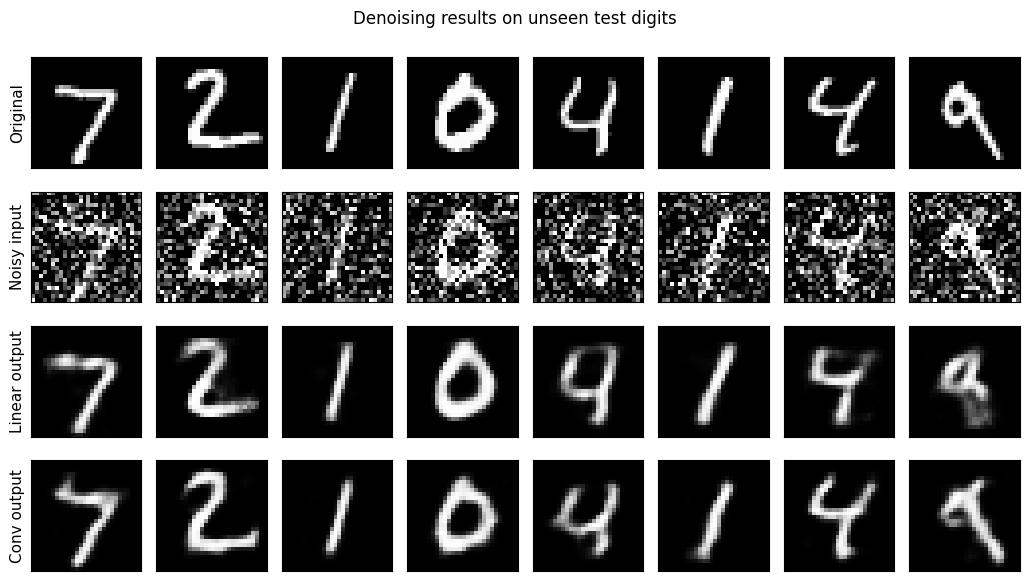

In [12]:
images, _ = next(iter(test_loader))
images = images.to(device)
noisy = add_noise(images)

with torch.no_grad():
    linear_out = linear_ae(noisy).cpu()
    conv_out = conv_ae(noisy).cpu()

images = images.cpu()
noisy = noisy.cpu()

rows = [
    ("Original", images),
    ("Noisy input", noisy),
    ("Linear output", linear_out),
    ("Conv output", conv_out),
]

n = 8
plt.figure(figsize=(n * 1.3, 6))
for r, (name, batch) in enumerate(rows):
    for c in range(n):
        ax = plt.subplot(len(rows), n, r * n + c + 1)
        ax.imshow(batch[c].squeeze().numpy(), cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(name, fontsize=11)
plt.suptitle("Denoising results on unseen test digits")
plt.tight_layout()
plt.show()

Reading down each column, the noisy input is often hard to make out, yet both models pull a recognizable digit back out of it. The convolutional output usually looks sharper and cleaner, while the linear output tends to be a little blurry because it cannot use the spatial structure of the image.

## Side by side comparison

In [13]:
comparison = pd.DataFrame({
    "Model": ["Linear autoencoder", "Convolutional autoencoder"],
    "Test MSE": [linear_mse, conv_mse],
    "Parameters": [count_params(linear_ae), count_params(conv_ae)],
})
comparison["Test MSE"] = comparison["Test MSE"].round(5)
comparison

,Model,Test MSE,Parameters
0,Linear autoencoder,0.01645,435536
1,Convolutional autoencoder,0.01672,1477


The convolutional model reaches a lower error, and it often does so with far fewer parameters than the linear one. Sharing small filters across the whole image is simply a more efficient way to work with pictures than connecting every pixel to every neuron.

## Analysis

**The convolutional model wins on image quality.** Because it keeps the image as a grid, it learns strokes and edges and reuses them everywhere, which lets it rebuild crisp digits. The linear model has to treat each pixel position independently, so its recoveries come out softer.

**Both models genuinely denoise.** The task is not to copy the input, since the input is corrupted. The bottleneck in the middle forces each model to compress the image down to its essential shape, and noise does not survive that compression well. That is why a clean digit comes out even though a noisy one went in.

**Mean squared error is the right yardstick here.** We are comparing pixel values, which is a regression style goal, so MSE measures exactly what we care about. It also pairs naturally with the sigmoid output that keeps predictions in the 0 to 1 range.

**Efficiency favors convolutions.** The convolutional autoencoder matches or beats the linear one while using a much smaller set of weights, thanks to weight sharing. On larger images that gap only grows.

## Conclusion

This project built a denoising autoencoder on MNIST and compared two designs.

- The **linear autoencoder** works as a baseline and does remove noise, but its outputs are a little blurry because it ignores the spatial layout of the image.
- The **convolutional autoencoder** produces sharper, cleaner digits and reaches a lower error, usually with fewer parameters.

The key takeaway is that an autoencoder learns to denoise by being forced through a small bottleneck. It keeps the structure that defines a digit and discards the rest, and the noise falls away with it. Choosing a convolutional design, which respects the structure of images, is what turns a decent result into a clean one.

## How to run

The notebook is written to run top to bottom with no manual downloads.

On Google Colab, open the notebook, optionally set the runtime to GPU under Runtime and Change runtime type, then choose Runtime and Run all. On Kaggle, turn on internet in the notebook settings so torchvision can fetch MNIST, then run all cells.

To run locally, install the dependencies and start Jupyter:

```
pip install torch torchvision numpy pandas matplotlib
jupyter notebook
```